# Linear Regression — Combined Cycle Power Plant Dataset

This notebook demonstrates ordinary least squares (OLS) and Ridge regression on the UCI Combined Cycle Power Plant dataset. By the end you will be able to:

- Fit OLS and Ridge models and compare their metrics side-by-side
- Observe how the Ridge penalty shrinks coefficients toward zero as regularisation strength increases
- Diagnose model fit using residual plots
- Visualise predicted vs. actual energy output for all three models simultaneously

## Mathematical Intuition

**Ordinary Least Squares** finds the coefficient vector $\boldsymbol{\beta}$ that minimises the sum of squared residuals:

$$\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

The closed-form solution is the **normal equation**:

$$\boldsymbol{\beta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

where $\mathbf{X} \in \mathbb{R}^{n \times p}$ is the design matrix, $\mathbf{y} \in \mathbb{R}^n$ is the target vector, and $\boldsymbol{\beta} \in \mathbb{R}^p$ is the solution.

**Ridge Regression** adds an $\ell_2$ penalty on the coefficients:

$$\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \alpha \|\boldsymbol{\beta}\|^2$$

The closed-form solution becomes:

$$\boldsymbol{\beta}_{\text{ridge}} = (\mathbf{X}^\top \mathbf{X} + \alpha \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}$$

- $\alpha$ is the regularisation strength. As $\alpha \to 0$ the solution approaches OLS; as $\alpha \to \infty$ all coefficients are driven toward zero.
- The penalty discourages large weights, reducing variance at the cost of a small increase in bias — useful when features are correlated or when $p$ is close to $n$.

## Dataset Overview

The **Combined Cycle Power Plant** dataset (UCI ID 294) contains 9,568 hourly measurements collected from a gas turbine power plant operating at full load.

| Feature | Type | Description |
|---------|------|-------------|
| AT | Continuous | Ambient temperature (°C) |
| V  | Continuous | Exhaust vacuum (cm Hg) |
| AP | Continuous | Ambient pressure (mbar) |
| RH | Continuous | Relative humidity (%) |
| **PE** | **Continuous** | **Net hourly electrical energy output (MW) — target** |

- **Rows:** 9,568  
- **Features:** 4  
- **Target:** PE (net energy output in MW)  
- **Missing values:** none

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from mlpackage import LinearRegression, StandardScaler, train_test_split

sns.set_style("whitegrid")

ccpp = fetch_ucirepo(id=294)
X_raw = ccpp.data.features
y_raw = ccpp.data.targets.values.ravel()

print("Features shape:", X_raw.shape)
print("Target shape:  ", y_raw.shape)
X_raw.head()

Features shape: (9568, 4)
Target shape:   (9568,)


,AT,V,AP,RH
0,14.96,41.76,1024.07,73.17
1,25.18,62.96,1020.04,59.08
2,5.11,39.40,1012.16,92.14
3,20.86,57.32,1010.24,76.64
4,10.82,37.50,1009.23,96.62


## Exploratory Data Analysis

In [2]:
df = X_raw.copy()
df["PE"] = y_raw

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:")
df.describe()

Shape: (9568, 5)

Missing values:
 AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Descriptive statistics:


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


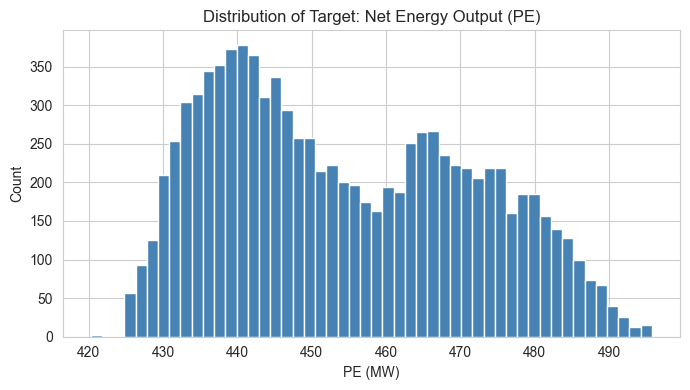

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_raw, bins=50, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Target: Net Energy Output (PE)")
ax.set_xlabel("PE (MW)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

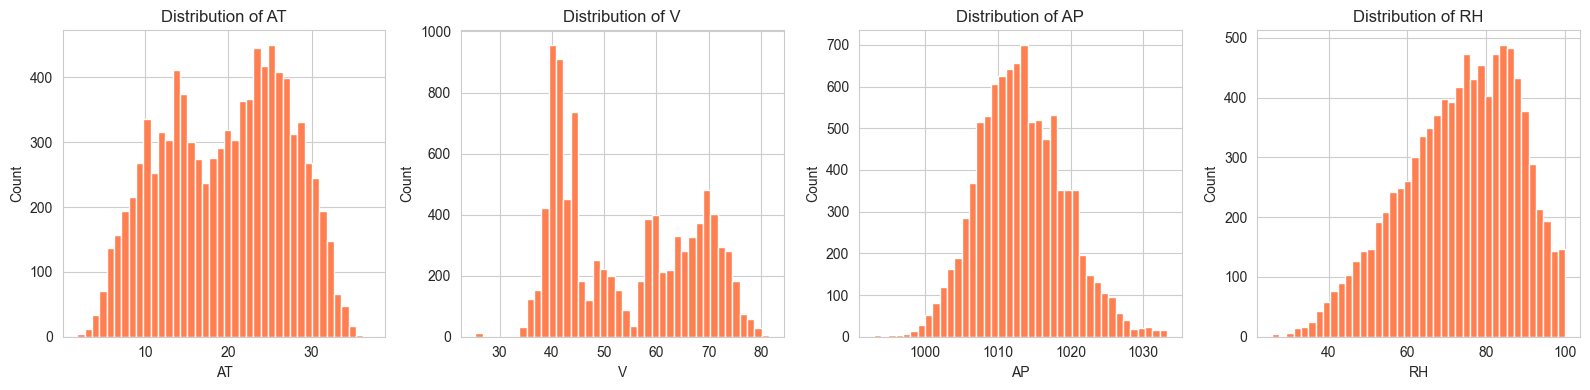

In [4]:
feature_names = list(X_raw.columns)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, feature_names):
    ax.hist(df[col], bins=40, color="coral", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

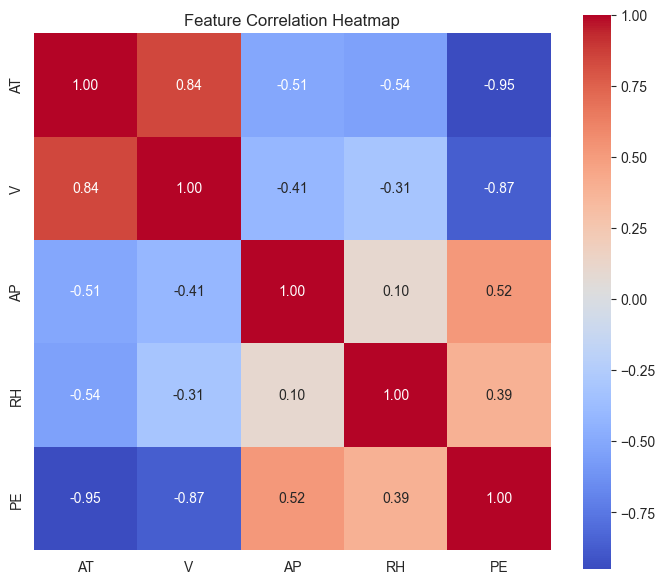

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

In [6]:
X = X_raw.values.astype(float)
y = y_raw.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]}  |  Test size: {X_test_scaled.shape[0]}")

Train size: 7654  |  Test size: 1914


## Model Training

In [7]:
model_ols        = LinearRegression(solver="ols")
model_ridge_low  = LinearRegression(solver="ridge", alpha=0.1)
model_ridge_high = LinearRegression(solver="ridge", alpha=100.0)

models = [
    ("OLS",             model_ols),
    ("Ridge alpha=0.1", model_ridge_low),
    ("Ridge alpha=100", model_ridge_high),
]

for name, model in models:
    model.fit(X_train_scaled, y_train)
    train_r2 = model.r2(X_train_scaled, y_train)
    test_r2  = model.r2(X_test_scaled,  y_test)
    print(f"{name:20s}  Train R2: {train_r2:.4f}  |  Test R2: {test_r2:.4f}")

OLS                   Train R2: 0.9281  |  Test R2: 0.9311
Ridge alpha=0.1       Train R2: 0.9281  |  Test R2: 0.9311
Ridge alpha=100       Train R2: 0.9276  |  Test R2: 0.9298


## Evaluation

In [8]:
rows = []
for label, model in models:
    rows.append({
        "Model":    label,
        "Train R2": round(model.r2(X_train_scaled, y_train), 4),
        "Test R2":  round(model.r2(X_test_scaled,  y_test),  4),
        "Test MSE": round(model.mse(X_test_scaled,  y_test), 4),
        "Test MAE": round(model.mae(X_test_scaled,  y_test), 4),
    })

summary = pd.DataFrame(rows).set_index("Model")
print(summary.to_string())

                 Train R2  Test R2  Test MSE  Test MAE
Model                                                 
OLS                0.9281   0.9311   20.0303    3.6240
Ridge alpha=0.1    0.9281   0.9311   20.0305    3.6241
Ridge alpha=100    0.9276   0.9298   20.3922    3.6527


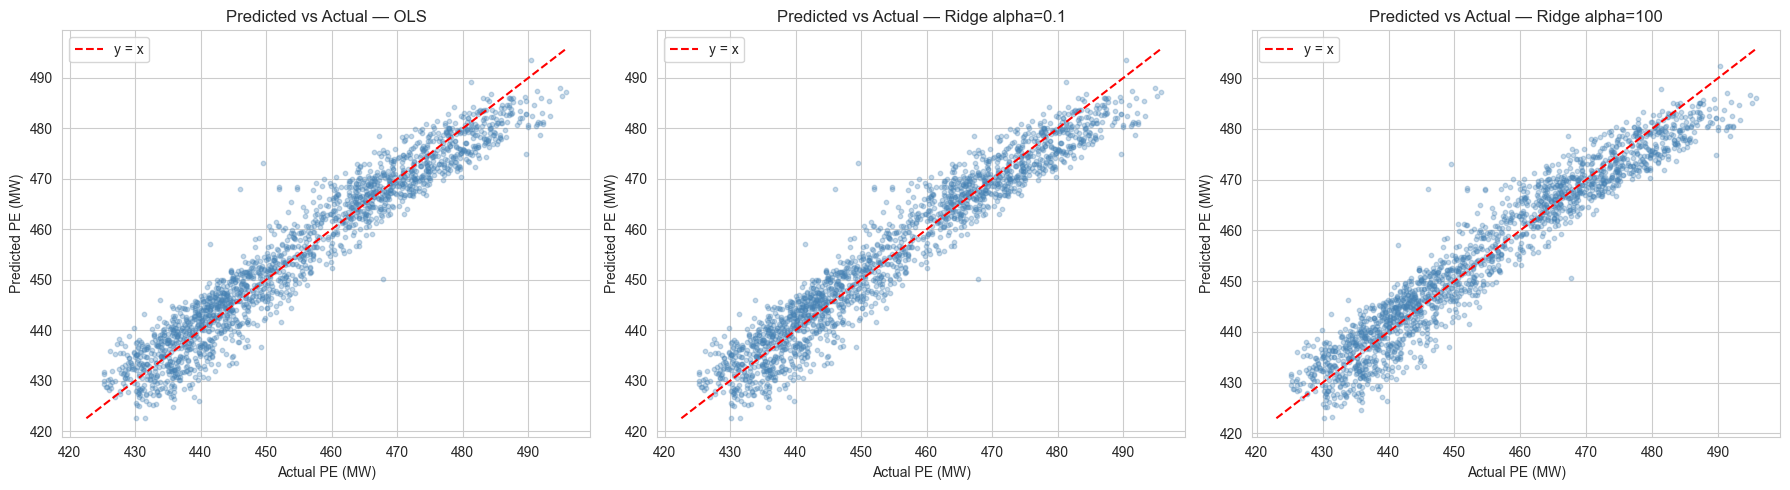

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, model) in zip(axes, models):
    y_pred = model.predict(X_test_scaled)
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="y = x")
    ax.set_title(f"Predicted vs Actual — {label}")
    ax.set_xlabel("Actual PE (MW)")
    ax.set_ylabel("Predicted PE (MW)")
    ax.legend()

plt.tight_layout()
plt.show()

## Visualisations

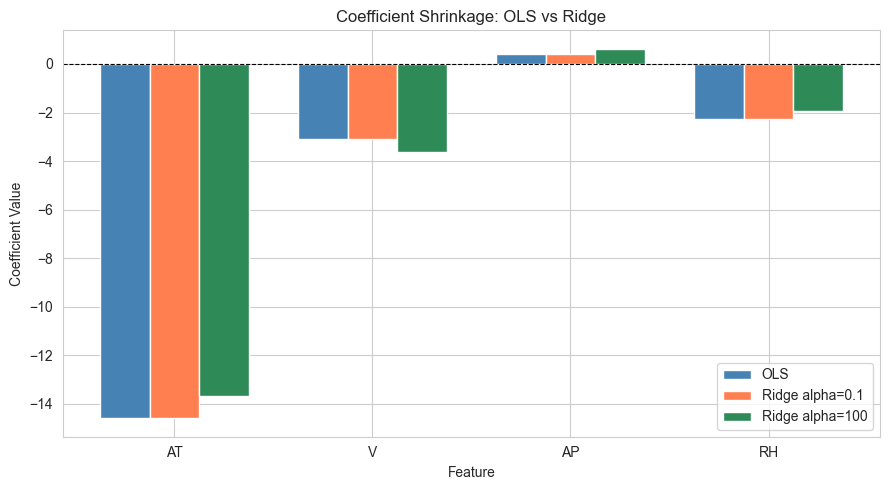

In [10]:
# Coefficient shrinkage: grouped bar chart
coef_matrix = np.column_stack([
    model_ols.coef_,
    model_ridge_low.coef_,
    model_ridge_high.coef_,
])

x     = np.arange(len(feature_names))
width = 0.25
colors = ["steelblue", "coral", "seagreen"]
labels = ["OLS", "Ridge alpha=0.1", "Ridge alpha=100"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (col, label) in enumerate(zip(coef_matrix.T, labels)):
    ax.bar(x + (i - 1) * width, col, width, label=label, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(feature_names)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Coefficient Shrinkage: OLS vs Ridge")
ax.set_xlabel("Feature")
ax.set_ylabel("Coefficient Value")
ax.legend()
plt.tight_layout()
plt.show()

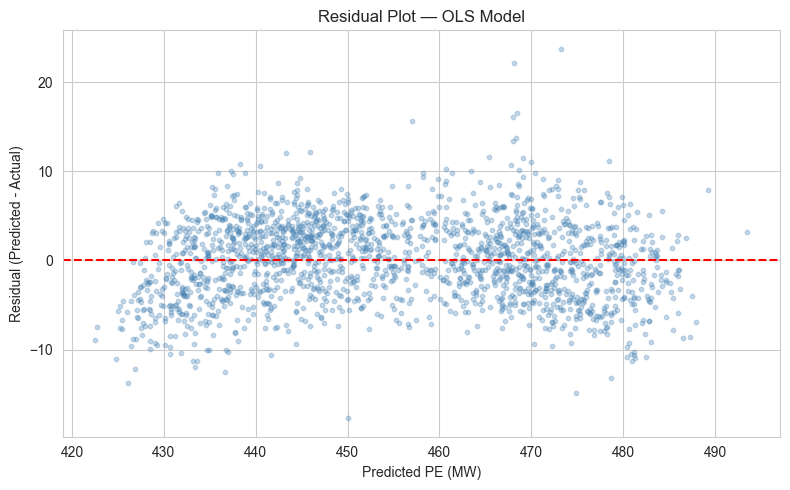

In [11]:
# Residual plot for OLS
y_pred_ols = model_ols.predict(X_test_scaled)
residuals   = y_pred_ols - y_test

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_ols, residuals, alpha=0.3, s=10, color="steelblue")
ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax.set_title("Residual Plot — OLS Model")
ax.set_xlabel("Predicted PE (MW)")
ax.set_ylabel("Residual (Predicted - Actual)")
plt.tight_layout()
plt.show()

## Interpretation and Conclusions

### Model Architecture: Strengths and Weaknesses

- **Ordinary Least Squares** minimises the sum of squared residuals in closed form via the normal equation $\boldsymbol{\beta} = (X^\top X)^{-1} X^\top y$: exact, with no hyperparameters, and statistically efficient under the Gauss-Markov assumptions.
- Each coefficient is directly interpretable as the **change in the target per unit increase in a feature**, holding all others fixed.
- **Ridge regression** adds an $\ell_2$ penalty that shrinks all coefficients toward zero, trading a small amount of bias for reduced variance; most useful when features are highly correlated or the number of features approaches the number of samples.
- The shared weakness of both methods is the **linearity assumption**: non-linear effects (such as curvature in the temperature-output relationship) are invisible to these models.

### Why It Worked on This Dataset

- The **CCPP dataset** has a near-linear structure in its four meteorological features: ambient temperature (AT) has the largest negative correlation with PE, exhaust vacuum (V) is strongly negatively correlated, and AP and RH are weaker but informative.
- Because these relationships are **largely monotone and additive**, a linear model captures most of the variance.
- Training and test $R^2$ values of **0.9281** and **0.9311** confirm that four continuous features with roughly linear effects are sufficient for this regression task.

### Results Grounded in the Graphs

- **OLS** achieves test $R^2 = 0.9311$, MSE $= 20.03$, MAE $= 3.62$ MW.
- **Ridge with $\alpha = 0.1$** is numerically identical to OLS: the penalty term is negligible relative to the scale of $X^\top X$.
- **Ridge with $\alpha = 100$** shrinks all coefficients visibly in the grouped bar chart, introducing bias that lowers test $R^2$ to **0.9298** and raises MSE to **20.39**: a direct illustration of the bias-variance trade-off.
- The **AT coefficient** is the largest negative value in all models: higher ambient temperature reduces turbine efficiency, consistent with thermodynamic principles.
- The **predicted-vs-actual scatter plots** for all three models show points clustered tightly along the $y = x$ diagonal across 420-496 MW, with no visible fanning or curvature.
- The **residual plot** for OLS shows residuals centred on zero with roughly constant spread, validating the linearity and homoscedasticity assumptions.